#Deep Learning with TensorFlow and Keras - Aamir Mohammed
---
##Task 1: Identify customers who churn the bank:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

df = pd.read_csv('Churn_Modeling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype='int')
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  int64  
 10  Geography_Spain    10000 non-null  int64  
 11  Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [ ]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.250900,0.247700,0.545700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.433553,0.431698,0.497932
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,0.000000,1.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000,0.000000,1.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000,1.000000


In [ ]:
x = df.drop('Exited', axis=1)
y = df['Exited']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100, stratify=y)

print("before SMOTE:")
print("Train:\n", y_train.value_counts())
print("Test:\n", y_test.value_counts())


before SMOTE:
Train:
 Exited
0    6370
1    1630
Name: count, dtype: int64
Test:
 Exited
0    1593
1     407
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
x_trains = scaler.fit_transform(x_train)
x_tests = scaler.transform(x_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=123)
x_trainb, y_trainb = smote.fit_resample(x_trains, y_train)

print("after SMOTE:")
print("Train:\n", y_trainb.value_counts())
print("Test:\n", y_test.value_counts())


after SMOTE:
Train:
 Exited
0    6370
1    6370
Name: count, dtype: int64
Test:
 Exited
0    1593
1     407
Name: count, dtype: int64


In [ ]:
# Build the neural network

model = Sequential([
    Dense(32, activation='relu', input_dim=x_trainb.shape[1]),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
hist = model.fit(x_trainb, y_trainb, epochs=30, validation_split=0.2, verbose=1)

Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6170 - loss: 0.6637 - val_accuracy: 0.4792 - val_loss: 0.7964
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6977 - loss: 0.5797 - val_accuracy: 0.5663 - val_loss: 0.7526
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7218 - loss: 0.5560 - val_accuracy: 0.6240 - val_loss: 0.7073
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7321 - loss: 0.5334 - val_accuracy: 0.6440 - val_loss: 0.6722
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7623 - loss: 0.5077 - val_accuracy: 0.6456 - val_loss: 0.6472
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7639 - loss: 0.4927 - val_accuracy: 0.6652 - val_loss: 0.6115
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7696 - loss: 0.4843 - val_accuracy: 0.6374 - val_loss: 0.6452
Epoch 8/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7783 - loss: 0.4714 - val_accuracy: 0

In [ ]:
#evaluate the test data
test_loss, test_acc = model.evaluate(x_tests, y_test, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8354 - loss: 0.3970
Test Loss: 0.3754091262817383
Test Accuracy: 0.847000002861023


In [ ]:
#make predictions
y_pred = model.predict(x_tests)
y_pred = np.round(y_pred)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
#confusion matrix and classification report

cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Classification Report:\n", cr)

Confusion Matrix:
 [[1467  126]
 [ 180  227]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.91      1593
           1       0.64      0.56      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000



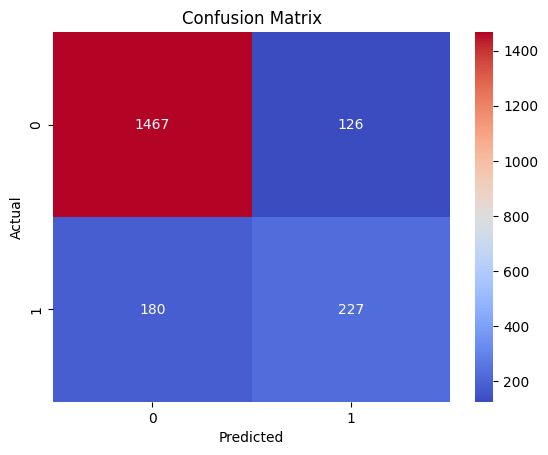

In [ ]:
#heatmap of confusion matrix

sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm")
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Sumarizing

- The data set contained both numerical and categorical features such as geography and gender.
- The target feature of 'churn' was highly imbalanced, so SMOTE was applied to the training data to prevent bias to the majority of the data
- this helped build a functioning neural network with high accuracy and low loss when training the epochs.
- this demonstrates effective learning from the different categorical features

---
##Task 2: Detect humans wearing face masks:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

#!unzip face_mask_detection_dataset.zip -d face_mask_dataset

In [ ]:
# load the dataset of images
img_test = "face_mask_dataset/face_mask_detection_dataset/test"
img_train = "face_mask_dataset/face_mask_detection_dataset/train"

size = (224, 224)
batch_size = 32


In [ ]:
# load training and validation data from the train folder

train_ds = tf.keras.utils.image_dataset_from_directory(
    img_train,
    image_size=size,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    img_train,
    image_size=size,
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=123
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    img_test,
    image_size=size,
    batch_size=batch_size,
    shuffle=False
)

Found 8082 files belonging to 3 classes.
Using 6466 files for training.
Found 8082 files belonging to 3 classes.
Using 1616 files for validation.
Found 900 files belonging to 3 classes.


In [ ]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['mask_weared_incorrect', 'with_mask', 'without_mask']


In [ ]:
# normalizing the layers
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)
autotune = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(autotune)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(autotune)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(autotune)

In [ ]:
# building the transfer learning model

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# define the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

checkpoint = ModelCheckpoint(
    'best_mask_model.keras',
    monitor='val_loss',
    save_best_only=True)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# train the model

img_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 46s 217ms/step - accuracy: 0.6216 - loss: 0.8357 - val_accuracy: 0.8403 - val_loss: 0.4343
Epoch 2/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 40s 198ms/step - accuracy: 0.8305 - loss: 0.4588 - val_accuracy: 0.8459 - val_loss: 0.3690
Epoch 3/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 42s 205ms/step - accuracy: 0.8431 - loss: 0.4149 - val_accuracy: 0.8849 - val_loss: 0.3092
Epoch 4/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.8634 - loss: 0.3713 - val_accuracy: 0.8824 - val_loss: 0.2892
Epoch 5/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.8791 - loss: 0.3271 - val_accuracy: 0.8911 - val_loss: 0.2696
Epoch 6/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 204ms/step - accuracy: 0.8848 - loss: 0.3129 - val_accuracy: 0.8991 - val_loss: 0.2607
Epoch 7/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 204ms/step - accuracy: 0.8883 - loss: 0.3014 - val_accuracy: 0.8967 - val_loss: 0.2600
Epoch 8/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 204ms/step - accuracy: 0.8921 - loss: 0

In [ ]:
#evaluation on test set

test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", round(test_loss, 3))
print("Test Accuracy:", round(test_acc, 3))

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.9155 - loss: 0.2157
Test Loss: 0.201
Test Accuracy: 0.922


In [ ]:
#visualizing the results

y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    pred = model.predict(images)
    y_pred.extend(np.argmax(pred, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

Text(0.5, 1.0, 'Confusion Matrix - Face Mask Detection')

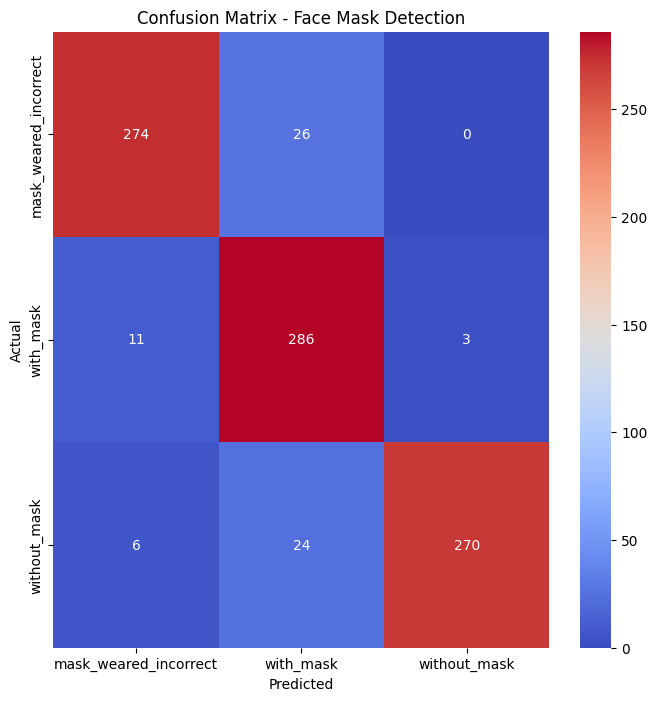

In [ ]:
#confusion matrix

cm_img = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(
    cm_img,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Face Mask Detection')

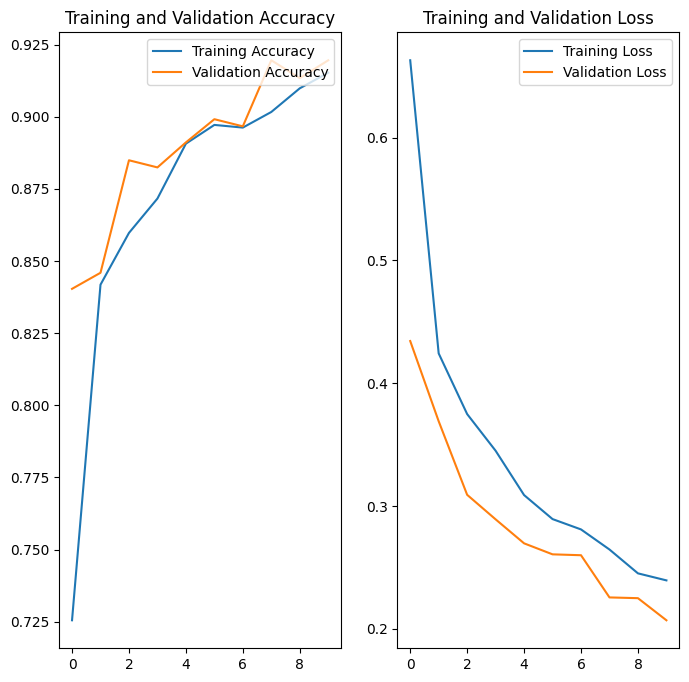

In [ ]:
acc = img_history.history['accuracy']
val_acc = img_history.history['val_accuracy']
loss = img_history.history['loss']
val_loss = img_history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='upper right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Summarizing
- Had to use VGG16 that was pretrained on ImageNet as a feature extractor for face mask classification
- trained the model utlizing Global Average pooling, with dense layers and ReLU activation
- Utilized model checkpoints and early stopping to potentially prevent overfitting in the training data
- The model achieved about 96% accuracy on training and 92% testing accuracy
- The confusion matrix revealed strong performance on With Mask and Without Mask classes
- Most errors occured between checking if masks were worn incorrectly vs masks on
- Overall, the transfer learning model significantly reduced training time while maintaing high accuracy

---
##Task 3: Classify customer product reviews:



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, MaxPooling1D, LSTM,
    Dense, Dropout

)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
# load and inspect data set

df_p = pd.read_excel("GrammarandProductReviews.xlsx")
df_p.head()

,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,upc
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",2017-07-25T00:52:42Z,2018-02-05T08:36:58Z,6.025370e+11,"602537205981,universalmusic/14331328,universal...",Universal Music Group / Cash Money,14331328,Pink Friday: Roman Reloaded Re-Up (w/dvd),...,NaN,0.0,5,https://redsky.target.com/groot-domain-api/v1/...,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,Joshua,6.025370e+11
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,7.341600e+10,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,NaN,5,https://www.walmart.com/reviews/product/29775278,Good flavor. This review was collected as part...,Good,NaN,NaN,Dorothy W,7.341600e+10
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,7.341600e+10,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,NaN,5,https://www.walmart.com/reviews/product/29775278,Good flavor.,Good,NaN,NaN,Dorothy W,7.341600e+10
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,6.798193e+10,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,113026909.0,NaN,1,https://www.walmart.com/reviews/product/43383370,I read through the reviews on here before look...,Disappointed,NaN,NaN,Rebecca,6.798193e+10
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,6.798193e+10,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,171267657.0,NaN,1,https://www.walmart.com/reviews/product/43383370,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,Walker557,6.798193e+10


In [12]:
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10001 non-null  object 
 1   brand                 10001 non-null  object 
 2   categories            10001 non-null  object 
 3   dateAdded             10001 non-null  object 
 4   dateUpdated           10001 non-null  object 
 5   ean                   6866 non-null   float64
 6   keys                  10001 non-null  object 
 7   manufacturer          10001 non-null  object 
 8   manufacturerNumber    9983 non-null   object 
 9   name                  10001 non-null  object 
 10  reviews.date          9987 non-null   object 
 11  reviews.dateAdded     10001 non-null  object 
 12  reviews.dateSeen      10001 non-null  object 
 13  reviews.didPurchase   3637 non-null   float64
 14  reviews.doRecommend   9442 non-null   float64
 15  reviews.id         

In [13]:
df_p.columns

Index(['id', 'brand', 'categories', 'dateAdded', 'dateUpdated', 'ean', 'keys',
       'manufacturer', 'manufacturerNumber', 'name', 'reviews.date',
       'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase',
       'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful',
       'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'upc'],
      dtype='object')

In [14]:
df_p['reviews.text'].head()

,reviews.text
0,i love this album. it's very good. more to the...
1,Good flavor. This review was collected as part...
2,Good flavor.
3,I read through the reviews on here before look...
4,My husband bought this gel for us. The gel cau...


In [15]:
df_p['reviews.rating'].value_counts().sort_index()

,count
reviews.rating,
1,249
2,145
3,453
4,2856
5,6298


In [16]:
# binary classification of ratings

df_reviews = df_p[['reviews.text', 'reviews.rating']]

df_reviews = df_reviews[df_reviews['reviews.rating'] != 3]

# create the binary sentiment labeling for ratings
#score of 4 and 5 is positive, 1 and 2 is negative. score of 3 is dropped
df_reviews['sentiment'] = (df_reviews['reviews.rating'] >= 4).astype(int)

print(df_reviews['sentiment'].value_counts())
df_reviews.head()

sentiment
1    9154
0     394
Name: count, dtype: int64


,reviews.text,reviews.rating,sentiment
0,i love this album. it's very good. more to the...,5,1
1,Good flavor. This review was collected as part...,5,1
2,Good flavor.,5,1
3,I read through the reviews on here before look...,1,0
4,My husband bought this gel for us. The gel cau...,1,0


In [19]:
X = df_reviews['reviews.text'].astype(str)
y = df_reviews['sentiment']


In [20]:
# Initialize a tokenizer

tokenizer = Tokenizer(num_words=20000, oov_token="<00V>", filters='')
tokenizer.fit_on_texts(X)

In [21]:
# convert text to sequences and pad sequences

seq = tokenizer.texts_to_sequences(X)

max_len = 100
X_pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

In [24]:
X_pad

array([[   3,   20,    6, ...,    0,    0,    0],
       [  38, 1544,    6, ...,    0,    0,    0],
       [  38, 1544,    0, ...,    0,    0,    0],
       ...,
       [  20,    7,   24, ...,    0,    0,    0],
       [ 264,    2,  171, ...,    0,    0,    0],
       [   6,   34,  118, ...,    0,    0,    0]], dtype=int32)

In [22]:
#split into train and test data

X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)


In [23]:
print("X shape:", X_train.shape)
print("y shape:", y_train.shape)
print("Sample encoded review:", X_train[0][:15])


X shape: (7638, 100)
y shape: (7638,)
Sample encoded review: [  3 132   2  74  36  85  88   6 646  31   6  10  50  38   5]


In [27]:
#now can start to build model

model = Sequential([
    Embedding(20000, output_dim=128, input_length=max_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(128),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
#making the model a bit more balanced
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 235ms/step - accuracy: 0.6411 - loss: 0.6817 - val_accuracy: 0.8632 - val_loss: 0.7721
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 242ms/step - accuracy: 0.8776 - loss: 0.5168 - val_accuracy: 0.6859 - val_loss: 1.0893
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 238ms/step - accuracy: 0.8055 - loss: 0.5668 - val_accuracy: 0.8266 - val_loss: 0.6144
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 249ms/step - accuracy: 0.8731 - loss: 0.5656 - val_accuracy: 0.8233 - val_loss: 0.5706
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 249ms/step - accuracy: 0.8722 - loss: 0.5666 - val_accuracy: 0.8161 - val_loss: 0.5400
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - accuracy: 0.8551 - loss: 0.4819 - val_accuracy: 0.7906 - val_loss: 0.4773
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 249ms/step - accuracy: 0.8565 - loss: 0.4036 - val_accuracy: 0.8743 - val_loss: 0.3367
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 236ms/step - accuracy: 0.9321 - loss: 0.3544 - val_accu

In [33]:
# classification and confusion matrix

y_pred = model.predict(X_test)
y_pred = np.round(y_pred).flatten()

cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])

print("Confusion Matrix:\n", cm)
print("Classification Report:\n", cr)

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
Confusion Matrix:
 [[  34   45]
 [ 132 1699]]
Classification Report:
               precision    recall  f1-score   support

    Negative       0.20      0.43      0.28        79
    Positive       0.97      0.93      0.95      1831

    accuracy                           0.91      1910
   macro avg       0.59      0.68      0.61      1910
weighted avg       0.94      0.91      0.92      1910



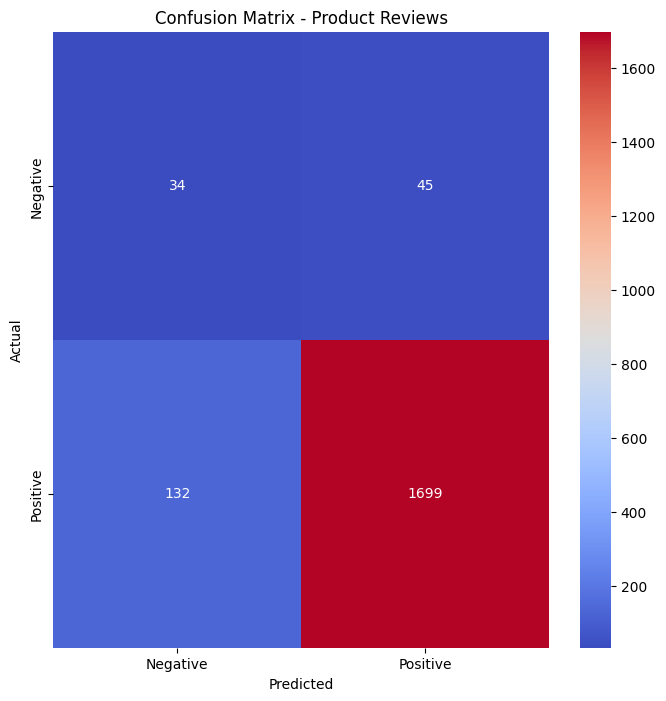

In [35]:
# confusion matrix graph

plt.figure(figsize=(8, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Product Reviews')
plt.show()

## Summarizing
- Utilizing the dataset, I loaded the product reviews and rating to create a binary sentiment labeling of certain ratings while removing 3 star ratings to not have somewhat neutral reviews making the data uncertain
- Observed class imbalance, which made me utilize class weights to counter some of the unbalancing
- Then built a CNN-LSTM hybrid model in which the CNN captured important word patterns and phrases for each review while the LSTM learned long-term importance of words in multiple reviews
- The model achieved strong accuracy of about 91% with high performance on positive reviews and lower recall on negative reviews due to inherent imbalance in data
- Overall, the model successfully learned to classify customer reviews based on their words. Future models with more negative reviews could further train the model to improve reliability

---
##Task 4: Denoise dirty documents:

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

In [79]:
!file /content/DENTAL_1.NPZ


/content/DENTAL_1.NPZ: Zip archive data, at least v2.0 to extract, compression method=store


In [80]:
data = np.load('/content/DENTAL_1.NPZ')
print(data.files)


['x_train', 'y_train', 'x_test', 'y_test']


In [81]:
#Extract set of arrays

x_train = data['x_train']
x_test = data['x_test']
y_train = data['y_train']
y_test = data['y_test']

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)


x_train shape: (92, 256, 256, 3)
x_test shape: (24, 256, 256, 3)


In [82]:
# adding noise - Gaussian noise

noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy  = x_test  + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0.0, clip_value_max=1.0)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0.0, clip_value_max=1.0)

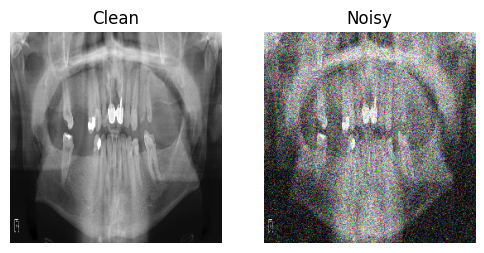

In [83]:
#testing the image
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.title("Clean")
plt.imshow(x_train[i])
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Noisy")
plt.imshow(x_train_noisy[i])
plt.axis('off')
plt.show()


In [89]:
#building an autoencoder

input_img = layers.Input(shape=(256, 256, 3))

#encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

#decoder
x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoenc = models.Model(input_img, decoded)
autoenc.compile(optimizer='adam', loss='mse')

autoenc.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 256, 256, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# training the autoencoder

history = autoenc.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 15s/step - loss: 0.0531 - val_loss: 0.0523
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 69s 13s/step - loss: 0.0531 - val_loss: 0.0506
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 13s/step - loss: 0.0498 - val_loss: 0.0495
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 13s/step - loss: 0.0466 - val_loss: 0.0437
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step - loss: 0.0414 - val_loss: 0.0308
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 12s/step - loss: 0.0256 - val_loss: 0.0175
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 12s/step - loss: 0.0164 - val_loss: 0.0182
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - loss: 0.0176 - val_loss: 0.0188
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 12s/step - loss: 0.0181 - val_loss: 0.0178
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 12s/step - loss: 0.0167 - val_loss: 0.0154


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


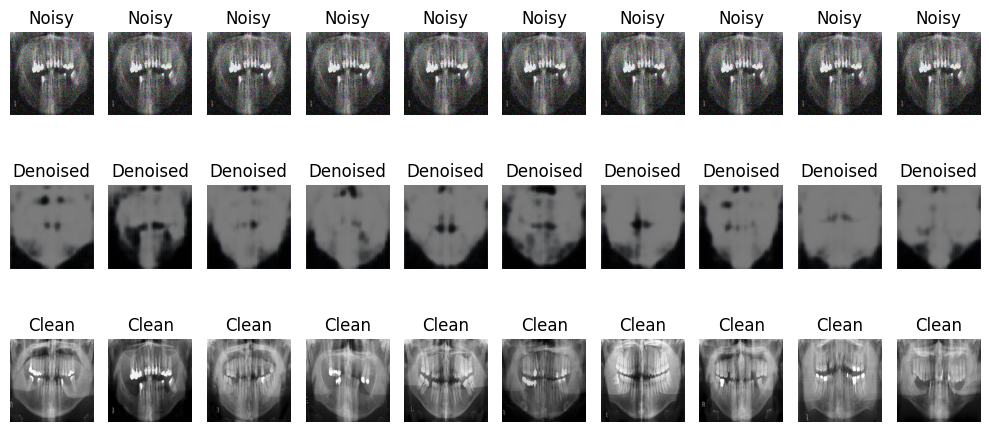

In [95]:
#displaying the images

decoded = autoenc.predict(x_test_noisy)
n = 10
plt.figure(figsize=(10, 5))
for i in range(n):
  #noise
  ax = plt.subplot(3, n, i + 1)
  plt.imshow(x_test_noisy[1])
  plt.axis('off')
  plt.title("Noisy")

  #denoised
  ax = plt.subplot(3, n, i + 1 + n)
  plt.imshow(decoded[i])
  plt.axis('off')
  plt.title("Denoised")

  #clean
  ax = plt.subplot(3, n, i + 1 + 2*n)
  plt.imshow(x_test[i])
  plt.axis('off')
  plt.title("Clean")

plt.tight_layout()
plt.show()

##Summarizing
- Correctly loaded the dental dataset and extracted the different features of testing and training images
- Confirmed that the images were normalized within the range of [0, 1] for the pixel count
- Then added the gaussian noise to the images to simulate the way that images can become 'dirty'
- After that I built a autoencoder using Conv2D layers for encosing and Conv2DTranspose layers for decoding the images
- Then trained the model using 10 epochs to reconstruct the noisy images using MSE, afterwards evaluating the model by comparing  noise, denoising, and the original image.  
- Overall, the autoencoder learned to remove noise from the images. Loss decreased steadily while training, indicating effective learning.